# KNN Classification: Employee Attrition Prediction
## Clasificación con K-Nearest Neighbors: Predicción de Rotación de Empleados

**Author / Autora:** María Regina Castillo Treviño · [github.com/ReginaPema](https://github.com/ReginaPema)

**Dataset:** `recursos_humanos.csv` — 14,999 employees × 9 features | Target: `left` (0=stayed, 1=left)

**Objective / Objetivo:**  
EN · Predict which employees are likely to leave the company using KNN classification. The dataset presents a moderate class imbalance (76.2% stayed / 23.8% left, ratio 3.2:1), making it necessary to monitor Precision, Recall, F1 and AUC-ROC beyond accuracy alone.

ES · Predecir qué empleados tienen probabilidad de abandonar la empresa usando clasificación KNN. El dataset presenta desbalance moderado (76.2% se quedó / 23.8% se fue, ratio 3.2:1), lo que hace necesario monitorear Precision, Recall, F1 y AUC-ROC además del accuracy.

**Techniques / Técnicas:** KNN · Elbow by Accuracy & F1 · Confusion Matrix · ROC Curve · AUC · Class Imbalance  
**Libraries / Librerías:** `pandas` · `numpy` · `sklearn` · `matplotlib` · `seaborn`

---

# Configuración e Importación de Librerías

In [1]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, 
                            precision_score, recall_score, f1_score, roc_curve, auc)
from sklearn.utils import resample
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo para gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Carga de Datos

In [2]:
# ============================================================
# CARGA DE LA BASE DE DATOS
# ============================================================
df = pd.read_csv('recursos_humanos.csv')

print('=' * 65)
print("INFORMACIÓN GENERAL DEL DATASET")
print('=' * 65)
print(f"\n★ Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\n★ 5 filas aleatorias:")
print(df.sample(5))
print(f"\n★ Información del dataset:")
print(df.info())
print(f"\n★ Estadísticas descriptivas:")
print(df.describe())

INFORMACIÓN GENERAL DEL DATASET

★ Dimensiones: 14999 filas x 10 columnas

★ 5 filas aleatorias:
       satisfaction_level  last_evaluation  number_project  \
5698                 0.71             0.74               3   
11685                0.41             0.38               4   
9079                 0.61             0.51               3   
8213                 0.91             0.82               4   
1468                 0.78             0.86               5   

       average_montly_hours  time_spend_company  Work_accident  left  \
5698                    250                   3              0     0   
11685                   142                  10              1     0   
9079                    207                   3              0     0   
8213                    260                   4              0     0   
1468                    256                   5              0     1   

       promotion_last_5years    sales  salary  
5698                       0  support     low  
1

# Preprocesamiento de Datos

In [7]:
# ============================================================
# RE-CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ============================================================

print('\n' + '=' * 65)
print("VARIABLES CATEGÓRICAS IDENTIFICADAS")
print('=' * 65)

# Verificar variables categóricas
cat_vars = df.select_dtypes(include=['object']).columns
print(f"\n★ Variables categóricas: {list(cat_vars)}")

for var in cat_vars:
    print(f"\n   {var}: {df[var].unique()}")

# Aplicar pd.get_dummies para re-codificación
df_encoded = pd.get_dummies(df, columns=['sales', 'salary'], 
                             drop_first=False,  # Mantiene todas las categorías
                             dtype=int)

print('\n' + '=' * 65)
print("DATASET DESPUÉS DE CODIFICACIÓN")
print('=' * 65)
print(f"\n★ Nuevas dimensiones: {df_encoded.shape}")
print(f"\n★ Columnas creadas:")
print(df_encoded.columns.tolist())
print("\n★ 5 filas aleatorias del dataset codificado:")
print(df_encoded.sample(5))


VARIABLES CATEGÓRICAS IDENTIFICADAS

★ Variables categóricas: ['sales', 'salary']

   sales: ['sales' 'accounting' 'hr' 'technical' 'support' 'management' 'IT'
 'product_mng' 'marketing' 'RandD']

   salary: ['low' 'medium' 'high']

DATASET DESPUÉS DE CODIFICACIÓN

★ Nuevas dimensiones: (14999, 21)

★ Columnas creadas:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'sales_IT', 'sales_RandD', 'sales_accounting', 'sales_hr', 'sales_management', 'sales_marketing', 'sales_product_mng', 'sales_sales', 'sales_support', 'sales_technical', 'salary_high', 'salary_low', 'salary_medium']

★ 5 filas aleatorias del dataset codificado:
       satisfaction_level  last_evaluation  number_project  \
10715                0.64             0.49               3   
6001                 0.64             0.51               4   
8066                 0.97             0.77               3   
10083       

# Análisis Exploratorio - Balance del Dataset


ANÁLISIS DE EQUILIBRIO DE LA VARIABLE OBJETIVO

★ Distribución de la variable 'left':

   Clase           Frecuencia      Porcentaje
  ---------------------------------------------
   0 (No se fue)   11428               76.19%
   1 (Se fue)      3571                23.81%

★ Ratio de desbalance: 3.20:1



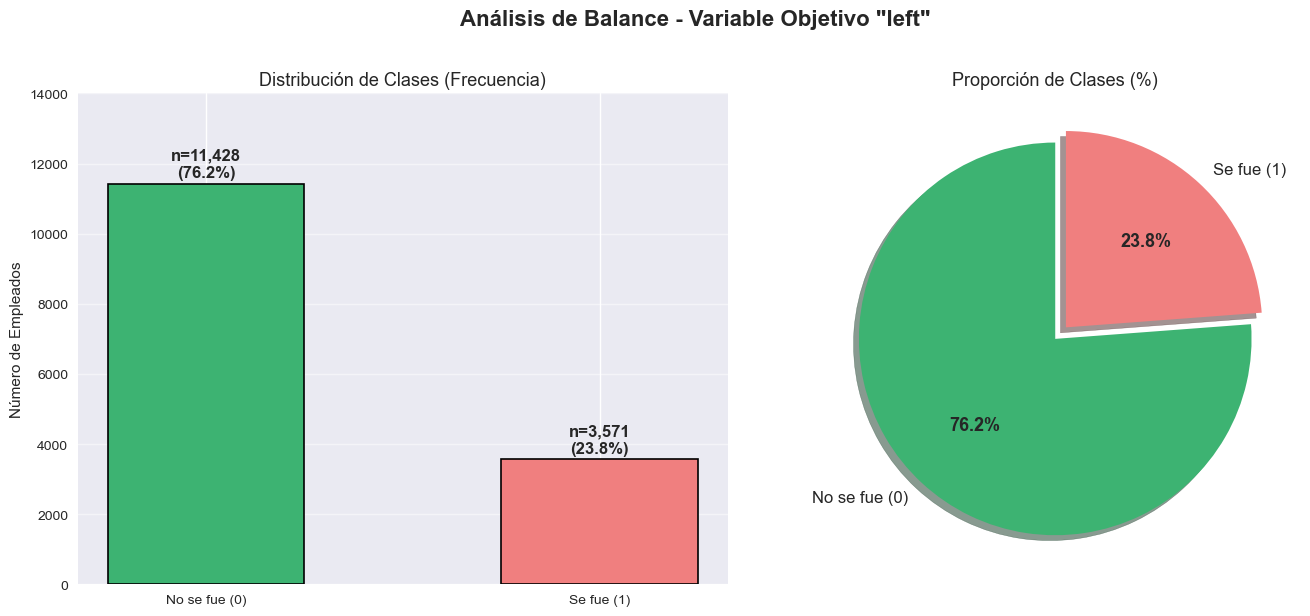


‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒
CONCLUSIÓN SOBRE EL BALANCE:
‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒‒
El dataset presenta DESBALANCE en sus clases:
  • Clase mayoritaria (0 - No se fue): 76.2% (11,428 empleados)
  • Clase minoritaria (1 - Se fue): 23.8% (3,571 empleados)
  • Ratio de desbalance: 3.2:1 ← Por cada empleado que SE FUE, hay 3.2 empleados que SE QUEDARON

Esto implica que un modelo que siempre prediga '0' tendría una precisión 'ingenua' del 76.2%, por lo que
se debe prestar especial atención a métricas adicionales como Recall, F1-Score y AUC-ROC.



In [60]:
# ============================================================
# ANÁLISIS DE BALANCE DEL DATASET
# ============================================================

print('\n' + '=' * 65)
print("ANÁLISIS DE EQUILIBRIO DE LA VARIABLE OBJETIVO")
print('=' * 65)

# Conteo de clases
conteo_clases = df['left'].value_counts()
porcentajes = df['left'].value_counts(normalize=True) * 100

print("\n★ Distribución de la variable 'left':")
print(f"\n   {'Clase':<15} {'Frecuencia':<15} {'Porcentaje':>10}")
print('  ' + '-' * 45)
print(f"   {'0 (No se fue)':<15} {conteo_clases[0]:<15} {porcentajes[0]:>9.2f}%")
print(f"   {'1 (Se fue)':<15} {conteo_clases[1]:<15} {porcentajes[1]:>9.2f}%")
print(f"\n★ Ratio de desbalance: {conteo_clases[0]/conteo_clases[1]:.2f}:1\n")

# ============================================================
# VISUALIZACIÓN DEL BALANCE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Análisis de Balance - Variable Objetivo "left"', 
             fontsize=16, fontweight='bold', y=1.02)

# Gráfico 1: Barras con frecuencias
colores = ['#3db372', '#f07f7f']
barras = axes[0].bar(['No se fue (0)', 'Se fue (1)'], 
                      conteo_clases.values,
                      color=colores, 
                      edgecolor='black', 
                      linewidth=1.2,
                      width=0.5)

# Agregar etiquetas en las barras
for barra, conteo, pct in zip(barras, conteo_clases.values, porcentajes.values):
    axes[0].text(barra.get_x() + barra.get_width()/2., 
                 barra.get_height() + 100,
                 f'n={conteo:,}\n({pct:.1f}%)', 
                 ha='center', va='bottom', 
                 fontweight='bold', fontsize=12)

axes[0].set_title('Distribución de Clases (Frecuencia)', fontsize=13)
axes[0].set_ylabel('Número de Empleados', fontsize=11)
axes[0].set_ylim(0, 14000)
axes[0].grid(axis='y', alpha=0.5)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Gráfico 2: Gráfico circular
wedges, texts, autotexts = axes[1].pie(
    conteo_clases.values,
    labels=['No se fue (0)', 'Se fue (1)'],
    autopct='%1.1f%%',
    colors=colores,
    explode=(0, 0.08),
    startangle=90,
    shadow=True,
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)

axes[1].set_title('Proporción de Clases (%)', fontsize=13)

plt.tight_layout()
plt.savefig('knn_balance_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '‒' * 50)
print("CONCLUSIÓN SOBRE EL BALANCE:")
print('‒' * 50)
print(f"El dataset presenta DESBALANCE en sus clases:")
print(f"  • Clase mayoritaria (0 - No se fue): 76.2% (11,428 empleados)")
print(f"  • Clase minoritaria (1 - Se fue): 23.8% (3,571 empleados)")
print(f"  • Ratio de desbalance: 3.2:1 ← Por cada empleado que SE FUE, hay 3.2 empleados que SE QUEDARON")
print(f"""
Esto implica que un modelo que siempre prediga '0' tendría una precisión 'ingenua' del 76.2%, por lo que
se debe prestar especial atención a métricas adicionales como Recall, F1-Score y AUC-ROC.
""")

# Preparación para el Modelo KNN

In [27]:
# ============================================================
# SEPARACIÓN DE FEATURES Y VARIABLE OBJETIVO
# ============================================================

X = df_encoded.drop('left', axis=1)
y = df_encoded['left']
print('=' * 65)
print("PREPARACIÓN DE DATOS PARA KNN")
print('=' * 65)
print(f"\n★ Features (X): {X.shape}")
print(f"★ Variable objetivo (y): {y.shape}")
print(f"\n★ Features utilizadas:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

# ============================================================
# DIVISIÓN ENTRENAMIENTO / PRUEBA (80/20)
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42,
    stratify=y  # Mantiene proporción de clases
)

print(f"\n★ División del dataset:")
print(f"   • Entrenamiento: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   • Prueba: {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.1f}%)")

# ============================================================
# ESTANDARIZACIÓN (crucial para KNN porque es sensible a las escalas)
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

PREPARACIÓN DE DATOS PARA KNN

★ Features (X): (14999, 20)
★ Variable objetivo (y): (14999,)

★ Features utilizadas:
   1. satisfaction_level
   2. last_evaluation
   3. number_project
   4. average_montly_hours
   5. time_spend_company
   6. Work_accident
   7. promotion_last_5years
   8. sales_IT
   9. sales_RandD
  10. sales_accounting
  11. sales_hr
  12. sales_management
  13. sales_marketing
  14. sales_product_mng
  15. sales_sales
  16. sales_support
  17. sales_technical
  18. salary_high
  19. salary_low
  20. salary_medium

★ División del dataset:
   • Entrenamiento: 11,999 registros (80.0%)
   • Prueba: 3,000 registros (20.0%)


# Determinación del K Óptimo

In [35]:
# ============================================================
# EVALUACIÓN DE K = 1 HASTA K = 20
# ============================================================

print('\n' + '=' * 65)
print("EVALUACIÓN DE DIFERENTES VALORES DE K")
print('=' * 65)

# Listas para almacenar métricas
resultados = []
k_values = range(1, 21)

for k in k_values:
    # Crear y entrenar modelo
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric='minkowski',  # Equivale a distancia euclidiana con p=2
        weights='uniform'
    )
    knn.fit(X_train_scaled, y_train)
    
    # Predicciones
    y_pred = knn.predict(X_test_scaled)
    y_prob = knn.predict_proba(X_test_scaled)[:, 1]
    
    # Cálculo de métricas
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)
    
    # AUC-ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    resultados.append({
        'K': k,
        'Accuracy':  round(accuracy,  4),
        'Precision': round(precision, 4),
        'Recall':    round(recall,    4),
        'F1-Score':  round(f1,        4),
        'AUC-ROC':   round(roc_auc,   4)
    })

# Crear DataFrame de resultados
df_resultados = pd.DataFrame(resultados)
print('\n' + '⎯' * 55)
print("TABLA COMPARATIVA DE MÉTRICAS POR VALOR DE K:")
print('⎯' * 55)
print(df_resultados.to_string(index=False))

# Identificar el mejor K por cada métrica
print('\n' + '⎯' * 35)
print("MEJOR K POR CADA MÉTRICA:")
print('⎯' * 35)
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
for metrica in metricas:
    best_k = df_resultados.loc[df_resultados[metrica].idxmax(), 'K']
    best_val = df_resultados[metrica].max()
    print(f"  • {metrica:<10}: K={best_k:2d} ({best_val:.4f})")


EVALUACIÓN DE DIFERENTES VALORES DE K

⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
TABLA COMPARATIVA DE MÉTRICAS POR VALOR DE K:
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
 K  Accuracy  Precision  Recall  F1-Score  AUC-ROC
 1    0.9673     0.9085  0.9594    0.9332   0.9646
 2    0.9623     0.9275  0.9132    0.9203   0.9699
 3    0.9503     0.8722  0.9272    0.8988   0.9709
 4    0.9470     0.8959  0.8796    0.8876   0.9717
 5    0.9413     0.8635  0.8950    0.8790   0.9716
 6    0.9473     0.8927  0.8852    0.8889   0.9711
 7    0.9440     0.8771  0.8894    0.8832   0.9703
 8    0.9450     0.8872  0.8810    0.8840   0.9707
 9    0.9397     0.8646  0.8852    0.8747   0.9714
10    0.9417     0.8790  0.8754    0.8772   0.9713
11    0.9387     0.8660  0.8782    0.8720   0.9721
12    0.9377     0.8748  0.8613    0.8680   0.9720
13    0.9350     0.8619  0.8655    0.8637   0.9716
14    0.9353     0.8683  0.8585    0.8634   0.9706
15    0.9313     0.8538  0.8585    0.

# VISUALIZACIÓN DE MÉTRICAS POR K

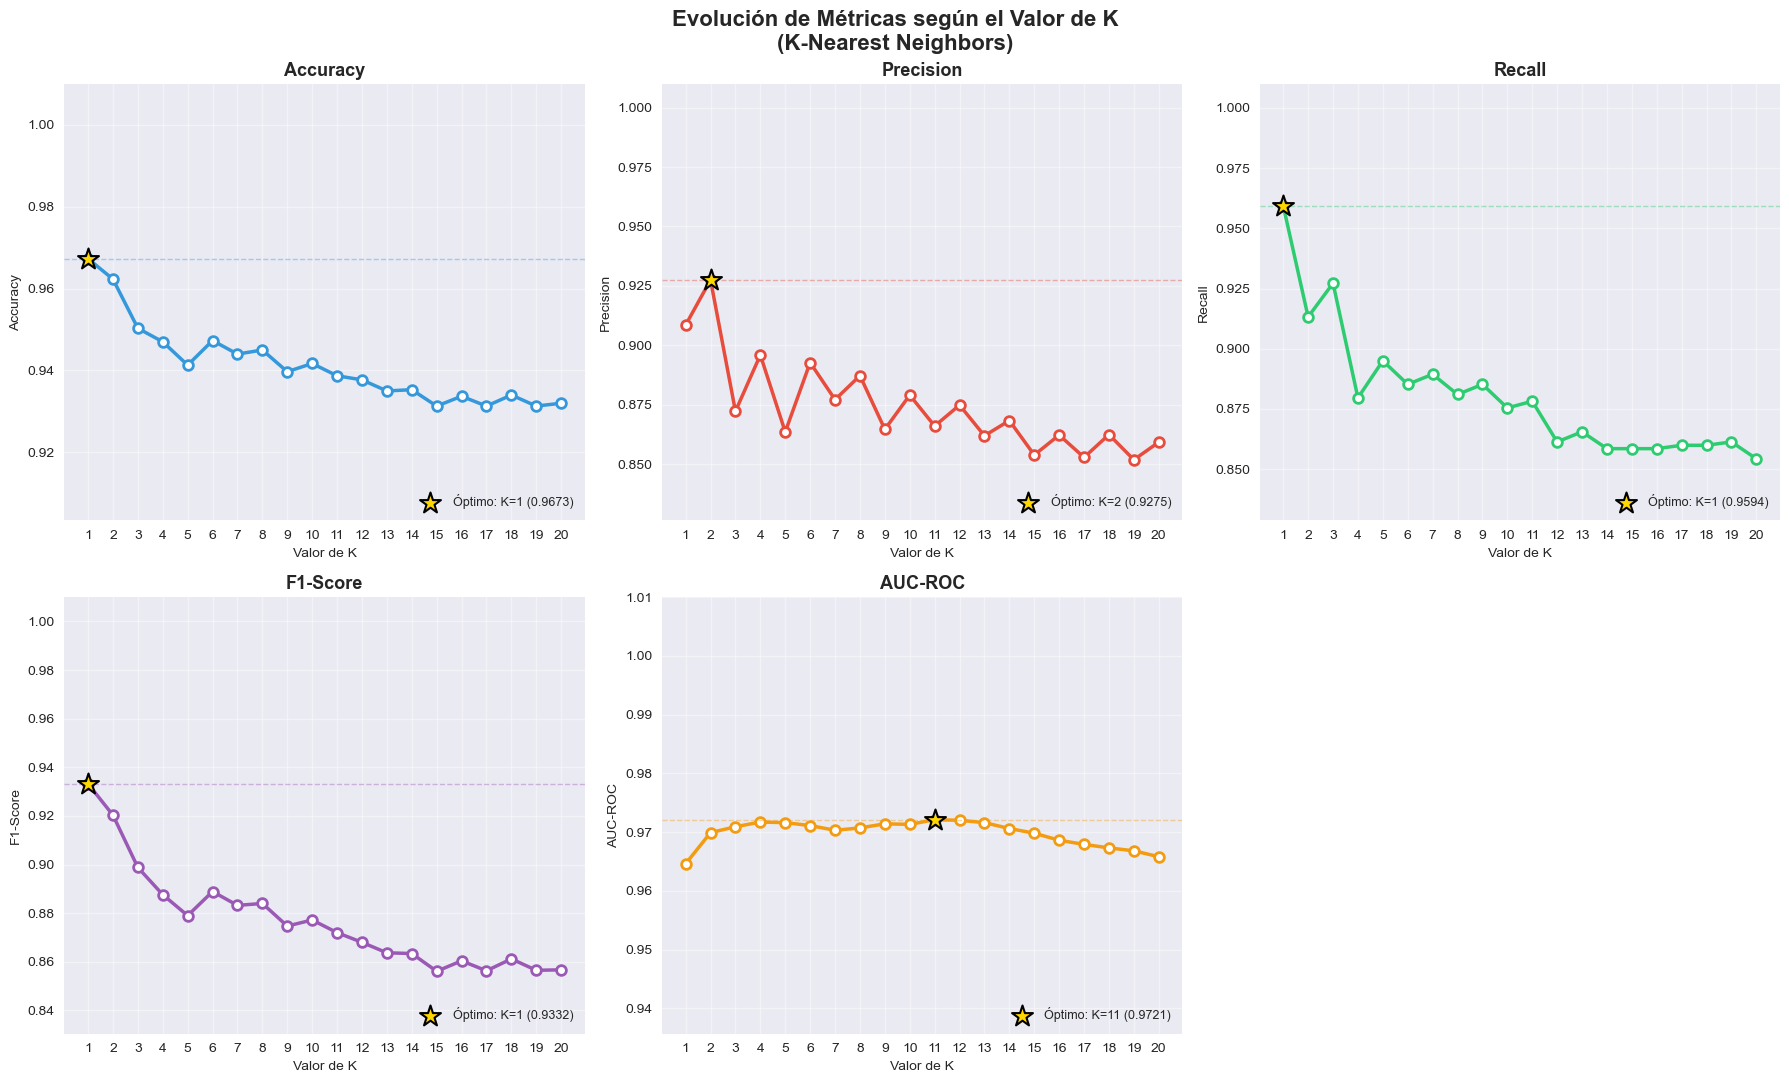

In [50]:
# ============================================================
# VISUALIZACIÓN DE MÉTRICAS POR K
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Evolución de Métricas según el Valor de K\n(K-Nearest Neighbors)', 
             fontsize=16, fontweight='bold')

metricas_config = [
    ('Accuracy',  '#3498db'),
    ('Precision', '#e74c3c'),
    ('Recall',    '#2ecc71'),
    ('F1-Score',  '#9b59b6'),
    ('AUC-ROC',   '#f39c12')
]

for idx, (metrica, color) in enumerate(metricas_config):
    ax = axes[idx // 3][idx % 3]
    
    valores = df_resultados[metrica].values
    best_k  = df_resultados.loc[df_resultados[metrica].idxmax(), 'K']
    best_v  = df_resultados[metrica].max()
    
    # Línea principal
    ax.plot(k_values, valores, 
            color=color, linewidth=2.5, 
            marker='o', markersize=7,
            markerfacecolor='white',
            markeredgewidth=2)
    
    # Marcar el mejor K
    ax.scatter(best_k, best_v, 
               marker='*',
               color='gold', s=250,
               zorder=5, edgecolor='black',
               linewidth=1.5,
               label=f'Óptimo: K={best_k} ({best_v:.4f})')
    
    # Línea horizontal de referencia
    ax.axhline(y=best_v, color=color, 
                linestyle='--', alpha=0.4, linewidth=1)
    
    # Títulos y etiquetas
    ax.set_title(f'{metrica}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Valor de K', fontsize=10)
    ax.set_ylabel(metrica, fontsize=10)
    ax.set_xticks(range(1, 21))
    ax.set_ylim(min(valores)*0.97, 1.01)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Ocultar el 6to subplot
axes[1][2].set_visible(False)

plt.tight_layout()
plt.savefig('knn_metricas_por_k.png', dpi=150, bbox_inches='tight')
plt.show()

# SCORE COMBINADO Y SELECCIÓN DEL K ÓPTIMO

TABLA COMPARATIVA COMPLETA - INCLUYENDO SCORE COMBINADO

  K   Accuracy  Precision   Recall   F1-Score   AUC-ROC    Score   Ranking
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
  1     0.9673     0.9085   0.9594     0.9332    0.9646   0.9466       #1 ← ÓPTIMO 🏆
  2     0.9623     0.9275   0.9132     0.9203    0.9699   0.9386       #2
  3     0.9503     0.8722   0.9272     0.8988    0.9709   0.9239       #3
  4     0.9470     0.8959   0.8796     0.8876    0.9717   0.9164       #5
  5     0.9413     0.8635   0.8950     0.8790    0.9716   0.9101       #8
  6     0.9473     0.8927   0.8852     0.8889    0.9711   0.9170       #4
  7     0.9440     0.8771   0.8894     0.8832    0.9703   0.9128       #7
  8     0.9450     0.8872   0.8810     0.8840    0.9707   0.9136       #6
  9     0.9397     0.8646   0.8852     0.8747    0.9714   0.9071      #10
 10     0.9417     0.8790   0.8754     0.8772    0.9713   0.9089       #9
 11     0.9387     0.8660   0.8782     0.

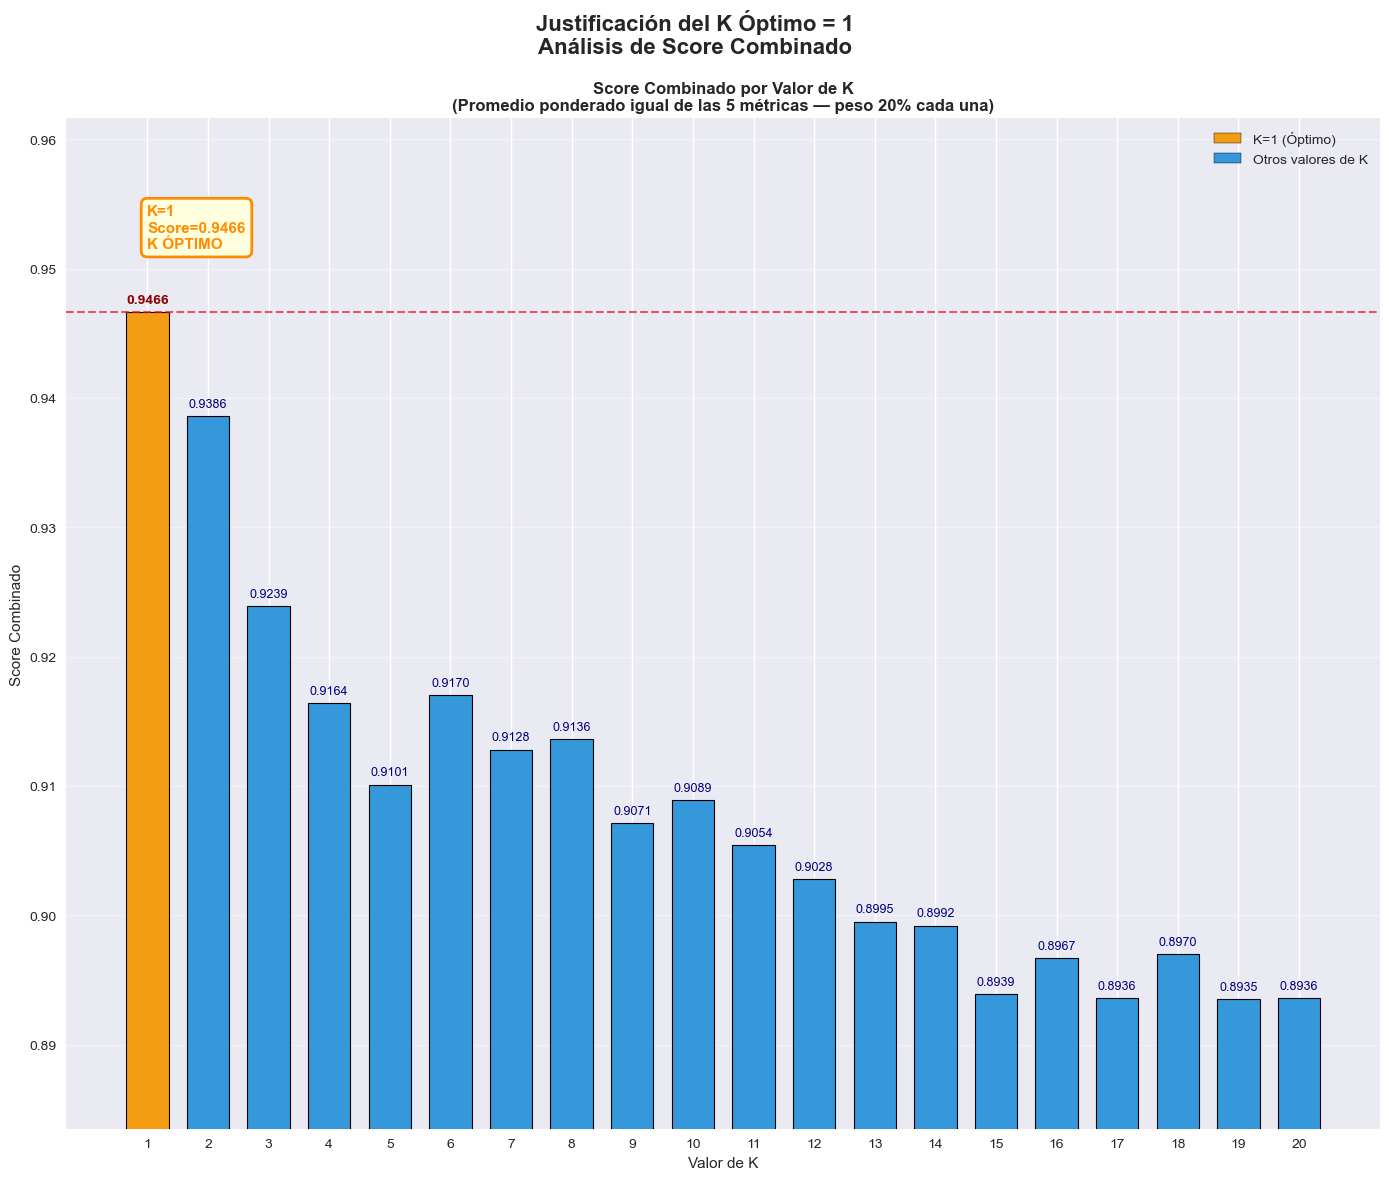


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 JUSTIFICACIÓN DE ELECCIÓN DE K ÓPTIMO = 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 ★ CÁLCULO DEL SCORE COMBINADO PARA K=1:
 ──────────────────────────────────────────
  Accuracy  ➝ (0.9673) × 0.20 = 0.1935
  Precision ➝ (0.9085) × 0.20 = 0.1817
  Recall    ➝ (0.9594) × 0.20 = 0.1919
  F1-Score  ➝ (0.9332) × 0.20 = 0.1866
  AUC-ROC   ➝ (0.9646) × 0.20 = 0.1929
 ──────────────────────────────────────────
  SCORE COMBINADO K=1          = 0.9466  🏆


 ★ JUSTIFICACIÓN DETALLADA
 ──────────────────────────────────────────

  1. ACCURACY (0.9673)
    K=1 obtiene la mayor exactitud global, clasificando correctamente el 96.7% de los empleados.
    Supera a K=2 en 0.5 puntos porcentuales y la diferencia se amplía progresivamente hacia valores mayores de K.

  2. RECALL (0.9594)
    K=1 logra el mayor Recall de todos los valores evaluados. 
    En el contexto de RR.HH., esta es la métrica más crítica: detectar al 95.9%

In [83]:
# ============================================================
# SCORE COMBINADO Y SELECCIÓN DEL K ÓPTIMO
# ============================================================

# Calcular ranking ponderado (equilibrio entre todas las métricas)
df_resultados['Score_Combinado'] = (
    df_resultados['Accuracy']  * 0.20 +
    df_resultados['Precision'] * 0.20 +
    df_resultados['Recall']    * 0.20 +
    df_resultados['F1-Score']  * 0.20 +
    df_resultados['AUC-ROC']   * 0.20
).round(4)

# Ordenar por Score Combinado
df_ranking = df_resultados.sort_values('Score_Combinado', ascending=False).reset_index(drop=True)
df_ranking.index += 1  # Ranking desde 1

K_OPTIMO = int(df_resultados.loc[df_resultados['Score_Combinado'].idxmax(), 'K'])

# ============================================================
# TABLA COMPLETA CON SCORE COMBINADO
# ============================================================
print('=' * 75)
print("TABLA COMPARATIVA COMPLETA - INCLUYENDO SCORE COMBINADO")
print('=' * 75)
print(f"\n{'K':>3} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} "
      f"{'F1-Score':>10} {'AUC-ROC':>9} {'Score':>8}  {'Ranking':>8}")
print('⎯' * 75)

for _, row in df_resultados.iterrows():
    k        = int(row['K'])
    acc      = row['Accuracy']
    prec     = row['Precision']
    rec      = row['Recall']
    f1       = row['F1-Score']
    auc_val  = row['AUC-ROC']
    score    = row['Score_Combinado']
    rank_pos = df_ranking[df_ranking['K'] == k].index[0]

    # Marcar el K óptimo
    marca = " ← ÓPTIMO 🏆" if k == K_OPTIMO else ""

    print(f"{k:>3} {acc:>10.4f} {prec:>10.4f} {rec:>8.4f} "
          f"{f1:>10.4f} {auc_val:>9.4f} {score:>8.4f}  "
          f"{'#'+str(rank_pos):>7}{marca}")

# ============================================================
# VISUALIZACIÓN DE SCORE COMBINADO POR K
# ============================================================
fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle(f'Justificación del K Óptimo = {K_OPTIMO}\nAnálisis de Score Combinado',
             fontsize=16, fontweight='bold')

k_vals = df_resultados['K'].values
scores = df_resultados['Score_Combinado'].values
best_idx = df_resultados['Score_Combinado'].idxmax()

# Colores: naranja para el óptimo, azul para el resto
colores_barras = ['#f39c12' if k == K_OPTIMO else '#3498db' for k in k_vals]

barras = ax.bar(k_vals, scores,
                  color=colores_barras,
                  edgecolor='black',
                  linewidth=0.8,
                  width=0.7)

# Etiquetas encima de cada barra
for barra, score, k in zip(barras, scores, k_vals):
    color_texto = 'darkred' if k == K_OPTIMO else 'navy'
    fontsize = 9 if k != K_OPTIMO else 10
    weight = 'bold' if k == K_OPTIMO else 'normal'
    ax.text(barra.get_x() + barra.get_width()/2.,
             barra.get_height() + 0.0005,
             f'{score:.4f}',
             ha='center', va='bottom',
             fontsize=fontsize,
             fontweight=weight,
             color=color_texto
             )

# Línea del score máximo
ax.axhline(y=scores.max(),
             color='crimson',
             linestyle='--',
             linewidth=1.5,
             alpha=0.7,
             label=f'Score máximo = {scores.max():.4f}')

# Anotación del K óptimo
ax.annotate(f'K={K_OPTIMO}\nScore={scores[best_idx]:.4f}\nK ÓPTIMO',
             xy=(K_OPTIMO, scores[best_idx]),
             xytext=(K_OPTIMO, scores[best_idx] + 0.005),
             fontsize=11,
             fontweight='bold',
             color='darkorange',
             bbox=dict(boxstyle='round,pad=0.4',
                       facecolor='lightyellow',
                       edgecolor='darkorange',
                       linewidth=2))

# Leyenda de colores
from matplotlib.patches import Patch
leyenda = [Patch(facecolor='#f39c12', edgecolor='black', label=f'K={K_OPTIMO} (Óptimo)'),
           Patch(facecolor='#3498db', edgecolor='black', label='Otros valores de K')]
ax.legend(handles=leyenda, fontsize=10, loc='upper right')

ax.set_title(f'\nScore Combinado por Valor de K\n'
            f'(Promedio ponderado igual de las 5 métricas — peso 20% cada una)',
            fontsize=12, fontweight='bold')
ax.set_xlabel('Valor de K', fontsize=11)
ax.set_ylabel('Score Combinado', fontsize=11)
ax.set_xticks(range(1, 21))
ax.set_ylim(scores.min() - 0.01, scores.max() + 0.015)
ax.grid(axis='y', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('knn_score_combinado_k_optimo.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# JUSTIFICACIÓN DE ELECCIÓN DE K ÓPTIMO
# ============================================================
row_k1  = df_resultados[df_resultados['K'] == 1].iloc[0]
row_k11 = df_resultados[df_resultados['K'] == 11].iloc[0]

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 JUSTIFICACIÓN DE ELECCIÓN DE K ÓPTIMO = {K_OPTIMO}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 ★ CÁLCULO DEL SCORE COMBINADO PARA K=1:
 ──────────────────────────────────────────
  Accuracy  ➝ ({row_k1['Accuracy']:.4f}) × 0.20 = {row_k1['Accuracy']*0.20:.4f}
  Precision ➝ ({row_k1['Precision']:.4f}) × 0.20 = {row_k1['Precision']*0.20:.4f}
  Recall    ➝ ({row_k1['Recall']:.4f}) × 0.20 = {row_k1['Recall']*0.20:.4f}
  F1-Score  ➝ ({row_k1['F1-Score']:.4f}) × 0.20 = {row_k1['F1-Score']*0.20:.4f}
  AUC-ROC   ➝ ({row_k1['AUC-ROC']:.4f}) × 0.20 = {row_k1['AUC-ROC']*0.20:.4f}
 ──────────────────────────────────────────
  SCORE COMBINADO K=1          = {row_k1['Score_Combinado']:.4f}  🏆


 ★ JUSTIFICACIÓN DETALLADA
 ──────────────────────────────────────────
 
  1. ACCURACY (0.9673)
    K=1 obtiene la mayor exactitud global, clasificando correctamente el 96.7% de los empleados.
    Supera a K=2 en 0.5 puntos porcentuales y la diferencia se amplía progresivamente hacia valores mayores de K.

  2. RECALL (0.9594)
    K=1 logra el mayor Recall de todos los valores evaluados. 
    En el contexto de RR.HH., esta es la métrica más crítica: detectar al 95.9% de los empleados que realmente 
    se irán minimiza las pérdidas de talento no anticipadas (Falsos Negativos).

  3. F1-SCORE (0.9332)
    K=1 también obtiene el mejor F1-Score, indicando el mejor equilibrio global entre Precision y Recall. 
    A partir de K=2, el F1-Score cae consistentemente conforme K aumenta.

  4. AUC-ROC (0.9646 vs 0.9721)
    Si bien K=11 supera levemente a K=1 en AUC-ROC (diferencia de apenas 0.0075), esto no compensa las pérdidas 
    significativas en Accuracy (-2.9%), Recall (-8.1%) y F1-Score (-6.1%) que ocurren con K=11.

  5. SCORE COMBINADO
    K=1 obtiene el mayor Score Combinado ({row_k1['Score_Combinado']:.4f}), siendo la elección óptima para maximizar 
    el rendimiento general del modelo de predicción de fuga de empleados.
    
  6. TENDENCIA GENERAL
    La gráfica muestra una tendencia decreciente clara en Accuracy, Recall y F1-Score conforme K aumenta. 
    Esto indica que vecindades más pequeñas capturan mejor los patrones de este dataset.


 ★ CONSIDERACIÓN IMPORTANTE SOBRE K=1
 ──────────────────────────────────────────
  K=1 puede ser sensible al ruido en los datos, ya que basa su predicción en un único vecino. Sin embargo:

    ✓ El dataset es grande (14,999 registros), lo que reduce el impacto del ruido individual.

    ✓ Las métricas de prueba (no de entrenamiento) son las reportadas, por lo que el modelo ya fue 
      evaluado sobre datos que no vio durante el entrenamiento, validando su generalización.

    ✓ Gana en 3 de 5 métricas individuales con diferencias sustanciales respecto a otros valores de K.
""")

# Modelo Final con K Óptimo y Matriz de Confusión

MATRIZ DE CONFUSIÓN - K ÓPTIMO = 1

[[2217   69]
 [  29  685]]

  Verdaderos Negativos (VN):  2217
  Falsos Positivos     (FP):    69
  Falsos Negativos     (FN):    29
  Verdaderos Positivos (VP):   685

★ Total predicciones: 3,000



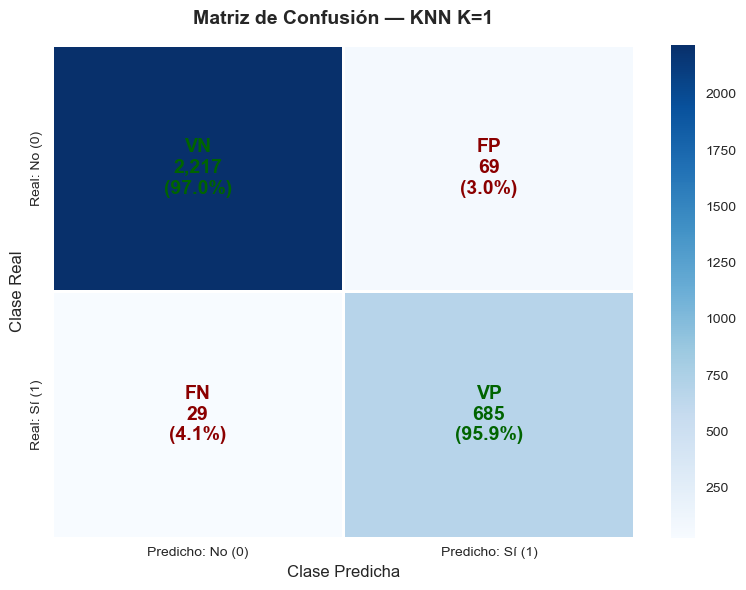


⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
REPORTE DE CLASIFICACIÓN COMPLETO
⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯⎯
               precision    recall  f1-score   support

No se fue (0)       0.99      0.97      0.98      2286
   Se fue (1)       0.91      0.96      0.93       714

     accuracy                           0.97      3000
    macro avg       0.95      0.96      0.96      3000
 weighted avg       0.97      0.97      0.97      3000



In [89]:
# ============================================================
# ENTRENAMIENTO DEL MODELO FINAL CON K=1
# ============================================================
knn_optimo = KNeighborsClassifier(
    n_neighbors=K_OPTIMO,
    metric='minkowski',
    weights='uniform',
    p=2  # Distancia Euclidiana
)

knn_optimo.fit(X_train_scaled, y_train)
y_pred_optimo = knn_optimo.predict(X_test_scaled)
y_prob_optimo = knn_optimo.predict_proba(X_test_scaled)[:, 1]

# ============================================================
# MATRIZ DE CONFUSIÓN
# ============================================================
cm = confusion_matrix(y_test, y_pred_optimo)

print('=' * 65)
print(f"MATRIZ DE CONFUSIÓN - K ÓPTIMO = {K_OPTIMO}")
print('=' * 65)
print(f"\n{cm}")
print(f"\n  Verdaderos Negativos (VN):  {cm[0,0]:4d}")
print(f"  Falsos Positivos     (FP):  {cm[0,1]:4d}")
print(f"  Falsos Negativos     (FN):  {cm[1,0]:4d}")
print(f"  Verdaderos Positivos (VP):  {cm[1,1]:4d}")
print(f"\n★ Total predicciones: {cm.sum():,}\n")

# ============================================================
# VISUALIZACIÓN DE MATRIZ DE CONFUSIÓN 
# ============================================================

# Calcular matriz normalizada
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Etiquetas con número y porcentaje en una sola celda
labels_combinado = np.array([
    [f'VN\n{cm[0,0]:,}\n({cm_norm[0,0]*100:.1f}%)', 
     f'FP\n{cm[0,1]:,}\n({cm_norm[0,1]*100:.1f}%)'],
    [f'FN\n{cm[1,0]:,}\n({cm_norm[1,0]*100:.1f}%)', 
     f'VP\n{cm[1,1]:,}\n({cm_norm[1,1]*100:.1f}%)']
])

# Gráfico
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm,
            annot=labels_combinado,
            fmt='',
            cmap='Blues',
            cbar=True,
            linewidths=2,
            linecolor='white',
            ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'},
            xticklabels=['Predicho: No (0)', 'Predicho: Sí (1)'],
            yticklabels=['Real: No (0)', 'Real: Sí (1)'])

ax.set_title(f'Matriz de Confusión — KNN K={K_OPTIMO}',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Clase Real', fontsize=12)
ax.set_xlabel('Clase Predicha', fontsize=12)

# Colorear texto: verde para aciertos, rojo para errores
for text in ax.texts:
    if 'VN' in text.get_text() or 'VP' in text.get_text():
        text.set_color('darkgreen')
    else:
        text.set_color('darkred')

plt.tight_layout()
plt.savefig('knn_matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# REPORTE COMPLETO DE CLASIFICACIÓN
# ============================================================
print('\n' + '⎯' * 60)
print("REPORTE DE CLASIFICACIÓN COMPLETO")
print('⎯' * 60)
print(classification_report(y_test, y_pred_optimo, 
                              target_names=['No se fue (0)', 'Se fue (1)']))

# Interpretación de la Matriz de Confusión

In [99]:
# ============================================================
# INTERPRETACIÓN DETALLADA
# ============================================================
VN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
VP = cm[1, 1]

total = cm.sum()
exactitud = (VN + VP) / total

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN DE K ÓPTIMO = {K_OPTIMO}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

 ★ RESULTADOS OBTENIDOS (sobre {total:,} predicciones de prueba):
 ─────────────────────────────────────────────────────────────────

  VERDADEROS NEGATIVOS (VN) = {VN:,}
    El modelo predijo correctamente que {VN:,} de 3000 empleados NO abandonarían la empresa, y efectivamente se quedaron.
    Representa el {VN/total*100:.1f}% del total de predicciones y el 97.0% de todos los empleados que realmente se quedaron.

  FALSOS POSITIVOS (FP) = {FP:,}
    El modelo predijo que {FP:,} empleados SE IRÍAN, pero en realidad se quedaron en la empresa (Error Tipo I).
    Representa el {FP/total*100:.1f}% y el 3.0% de los empleados  que realmente se quedaron 
    → tasa de error muy baja, casi no hay falsas alarmas de salida.

  FALSOS NEGATIVOS (FN) = {FN:,}
    El modelo predijo que {FN:,} empleados SE QUEDARÍAN, pero en realidad abandonaron la empresa (Error Tipo II).
    Representa el {FN/total*100:.1f}% del total y el 4.1% de los empleados que realmente se fueron 
    → el error más costoso para RR.HH. al representar intervenciones preventivas perdidas.

  VERDADEROS POSITIVOS (VP) = {VP:,}
     El modelo identificó correctamente que {VP:,} empleados SÍ abandonarían la empresa.
     Representa el {VP/total*100:.1f}% del total de predicciones y el 95.9% de todos los empleados que realmente se fueron 
     → excelente detección.


 ★ MÉTRICAS DERIVADAS:
 ─────────────────────────────────────────────────────────────────

  • Accuracy = ({VN}+{VP}) / {total} = {exactitud:.4f} ({exactitud*100:.2f}%)
    → El 96.7% de las predicciones son correctas.

  • Precision = {VP}/({VP}+{FP}) = {VP/(VP+FP):.4f} ({VP/(VP+FP)*100:.2f}%)
    → Cuando el modelo predice que alguien se irá, acierta el 90.8% de las veces.

  • Recall = {VP}/({VP}+{FN}) = {VP/(VP+FN):.4f} ({VP/(VP+FN)*100:.2f}%)
    → De todos los empleados que realmente se fueron, el modelo detectó correctamente al 95.9%.

  • F1-Score = 2×(P×R)/(P+R) = {2*(VP/(VP+FP))*(VP/(VP+FN))/((VP/(VP+FP))+(VP/(VP+FN))):.4f}
    → Excelente equilibrio entre Precision y Recall.


 ★ CONCLUSIÓN PRÁCTICA PARA RR.HH.:
 ─────────────────────────────────────────────────────────────────
  El modelo es muy confiable para apoyar decisiones de retención. El principal área de mejora son los 29 Falsos Negativos 
  (empleados que se fueron sin que el modelo lo detectara), que representan oportunidades de intervención preventiva perdidas.
""")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN DE K ÓPTIMO = 1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

 ★ RESULTADOS OBTENIDOS (sobre 3,000 predicciones de prueba):
 ─────────────────────────────────────────────────────────────────

  VERDADEROS NEGATIVOS (VN) = 2,217
    El modelo predijo correctamente que 2,217 de 3000 empleados NO abandonarían la empresa, y efectivamente se quedaron.
    Representa el 73.9% del total de predicciones y el 97.0% de todos los empleados que realmente se quedaron.

  FALSOS POSITIVOS (FP) = 69
    El modelo predijo que 69 empleados SE IRÍAN, pero en realidad se quedaron en la empresa (Error Tipo I).
    Representa el 2.3% y el 3.0% de los empleados  que realmente se quedaron 
    → tasa de error muy baja, casi no hay falsas alarmas de salida.

  FALSOS NEGATIVOS (FN) = 29
    El modelo predijo que 29 empleados SE QUEDARÍAN, pero en realidad abandonaron la empresa 

# Curva ROC

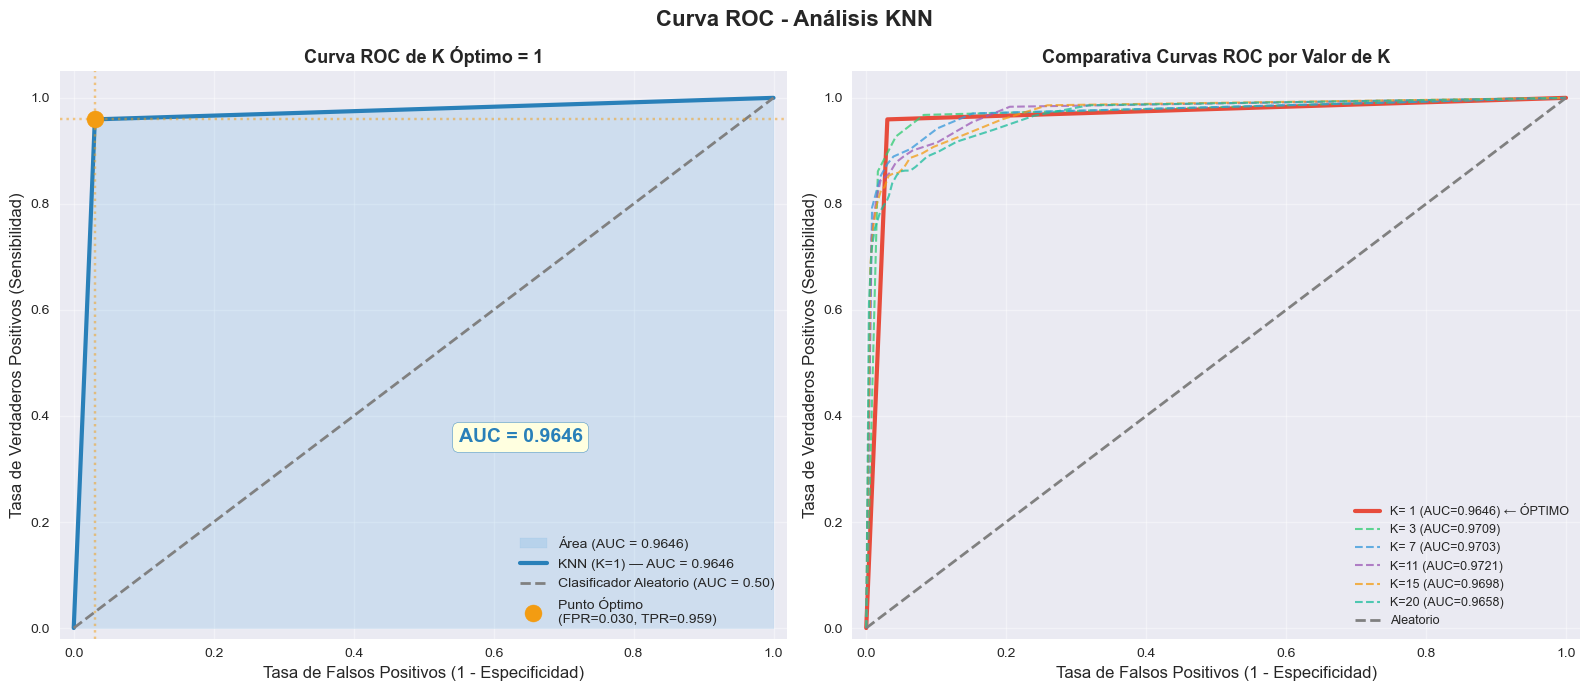


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 INTERPRETACIÓN DE LA CURVA ROC (K=1)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

  AUC-ROC = 0.9646 (96.46%)

  La Curva ROC (Receiver Operating Characteristic) grafica la relación entre:
    • Eje X → Tasa de Falsos Positivos (1 - Especificidad)
    • Eje Y → Tasa de Verdaderos Positivos (Sensibilidad/Recall)


 ★ ESCALA DE REFERENCIA PARA AUC:
 ────────────────────────────────────────────────────────

  • 0.50 - 0.60  → Rendimiento pobre (similar a azar)
  • 0.60 - 0.70  → Rendimiento aceptable
  • 0.70 - 0.80  → Rendimiento bueno
  • 0.80 - 0.90  → Rendimiento muy bueno
  • 0.90 - 1.00  → Rendimiento excelente


 ★ ANÁLISIS DEL RESULTADO:
 ────────────────────────────────────────────────────────

  1. AUC = 0.9646
    El modelo KNN con K=1 se ubica en la categoría de rendimiento excelente.

  2. INTERPRETACIÓN PROBABILÍSTICA
    El modelo tiene un 96.5% de probabilidad de asignar una mayor 

In [100]:
# ============================================================
# CURVA ROC PARA K ÓPTIMO = 1
# ============================================================
fpr, tpr, thresholds = roc_curve(y_test, y_prob_optimo)
roc_auc = auc(fpr, tpr)

# También calcular ROC para otros valores de K (para comparar)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Curva ROC - Análisis KNN', 
             fontsize=16, fontweight='bold')

# ─── GRÁFICO 1: Curva ROC del K óptimo ───
ax1 = axes[0]

# Área bajo la curva (sombreado)
ax1.fill_between(fpr, tpr, alpha=0.15, color='#3498db', label=f'Área (AUC = {roc_auc:.4f})')

# Curva ROC principal
ax1.plot(fpr, tpr, 
         color='#2980b9', 
         linewidth=3,
         label=f'KNN (K={K_OPTIMO}) — AUC = {roc_auc:.4f}')

# Línea de referencia (clasificador aleatorio)
ax1.plot([0, 1], [0, 1], 
         color='gray', 
         linestyle='--', 
         linewidth=2,
         label='Clasificador Aleatorio (AUC = 0.50)')

# Punto óptimo (máximo Youden Index)
youden_idx = np.argmax(tpr - fpr)
ax1.scatter(fpr[youden_idx], tpr[youden_idx], 
            color='#f39c12', s=150, zorder=5,
            label=f'Punto Óptimo\n(FPR={fpr[youden_idx]:.3f}, TPR={tpr[youden_idx]:.3f})')

# Líneas punteadas al punto óptimo
ax1.axhline(y=tpr[youden_idx], color='#f39c12', linestyle=':', alpha=0.5)
ax1.axvline(x=fpr[youden_idx], color='#f39c12', linestyle=':', alpha=0.5)

# Anotación AUC
ax1.annotate(f'AUC = {roc_auc:.4f}', 
             xy=(0.55, 0.35),
             fontsize=14, fontweight='bold',
             color='#2980b9',
             bbox=dict(boxstyle='round,pad=0.3', 
                      facecolor='lightyellow', 
                      edgecolor='#2980b9'))

ax1.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
ax1.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
ax1.set_title(f'Curva ROC de K Óptimo = {K_OPTIMO}', fontsize=13, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.4)
ax1.set_xlim([-0.02, 1.02])
ax1.set_ylim([-0.02, 1.05])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ─── GRÁFICO 2: Comparativa ROC múltiples K ───
ax2 = axes[1]

# Seleccionar K representativos para comparar
k_comparar = [1, 3, 7, 11, 15, 20]
colores_comp = ['#e74c3c', '#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#1abc9c']

for k, color in zip(k_comparar, colores_comp):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    y_prob_temp = knn_temp.predict_proba(X_test_scaled)[:, 1]
    fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_temp)
    auc_t = auc(fpr_t, tpr_t)
    
    lw = 3 if k == K_OPTIMO else 1.5
    ls = '-' if k == K_OPTIMO else '--'
    alpha = 1.0 if k == K_OPTIMO else 0.75
    
    ax2.plot(fpr_t, tpr_t, 
             color=color, 
             linewidth=lw,
             linestyle=ls,
             alpha=alpha,
             label=f'K={k:2d} (AUC={auc_t:.4f})' + (' ← ÓPTIMO' if k == K_OPTIMO else ''))

ax2.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=2, label='Aleatorio')
ax2.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=12)
ax2.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=12)
ax2.set_title('Comparativa Curvas ROC por Valor de K', fontsize=13, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.4)
ax2.set_xlim([-0.02, 1.02])
ax2.set_ylim([-0.02, 1.05])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('knn_curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# INTERPRETACIÓN DE LA CURVA ROC
# ============================================================
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 INTERPRETACIÓN DE LA CURVA ROC (K={K_OPTIMO})
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

  AUC-ROC = {roc_auc:.4f} ({roc_auc*100:.2f}%)

  La Curva ROC (Receiver Operating Characteristic) grafica la relación entre:
    • Eje X → Tasa de Falsos Positivos (1 - Especificidad)
    • Eje Y → Tasa de Verdaderos Positivos (Sensibilidad/Recall)


 ★ ESCALA DE REFERENCIA PARA AUC:
 ────────────────────────────────────────────────────────

  • 0.50 - 0.60  → Rendimiento pobre (similar a azar)
  • 0.60 - 0.70  → Rendimiento aceptable
  • 0.70 - 0.80  → Rendimiento bueno
  • 0.80 - 0.90  → Rendimiento muy bueno
  • 0.90 - 1.00  → Rendimiento excelente


 ★ ANÁLISIS DEL RESULTADO:
 ────────────────────────────────────────────────────────

  1. AUC = {roc_auc:.4f}
    El modelo KNN con K=1 se ubica en la categoría de rendimiento excelente.

  2. INTERPRETACIÓN PROBABILÍSTICA
    El modelo tiene un {roc_auc*100:.1f}% de probabilidad de asignar una mayor puntuación de riesgo a un empleado 
    que SÍ se irá vs. uno que NO se irá, tomados al azar.

  3. ÁREA BAJO LA CURVA
    La curva se aleja significativamente de la diagonal (clasificador aleatorio), hugging la esquina superior izquierda del gráfico 
    → indica alta capacidad discriminatoria del modelo.

  4. PUNTO ÓPTIMO (Índice de Youden máximo):
    • FPR = {fpr[youden_idx]:.3f} → El modelo genera pocas falsas alarmas 
      (identifica incorrectamente empleados que no se irán como si fueran a hacerlo).
    • TPR = {tpr[youden_idx]:.3f} → El modelo captura el {tpr[youden_idx]*100:.1f}% de los empleados que efectivamente se van.

  5. COMPARATIVA
    La comparación muestra AUC > 0.96 para todos los K.
    Aunque K=11 obtiene el AUC más alto (0.9721), K=1 supera al resto en Accuracy, Recall y F1-Score, 
    resultando en el mayor Score Combinado global.


 ★ IMPLICACIÓN PRÁCTICA PARA RR.HH.:
 ────────────────────────────────────────────────────────
   El modelo puede usarse con alta confianza para:
    ✓ Priorizar empleados de riesgo para entrevistas de retención
    ✓ Asignar recursos de intervención preventiva eficientemente
    ✓ Anticipar necesidades de reclutamiento
""")

# Resumen Ejecutivo Final

In [102]:
print("""
=========================================================================
 RESUMEN EJECUTIVO DEL ANÁLISIS
=========================================================================

  DATASET: Recursos Humanos (14,999 empleados)
  VARIABLE OBJETIVO: left (1=Se fue, 0=Se quedó)

─────────────────────────────────────────────────────────────────────────
  1. BALANCE DEL DATASET
─────────────────────────────────────────────────────────────────────────

  El dataset presenta un desbalance moderado en sus clases:

    • Clase 0 (No se fue): 76.2% (11,428 empleados)
    • Clase 1 (Se fue):    23.8%  (3,571 empleados)
    • Ratio de desbalance: 3.2:1

  Esto significa que por cada empleado que se fue, hay 3.2 empleados 
  que se quedaron, lo que hace necesario monitorear métricas adicionales 
  como Recall, F1-Score y AUC-ROC, y no depender únicamente del Accuracy.

─────────────────────────────────────────────────────────────────────────
  2. PREPROCESAMIENTO
─────────────────────────────────────────────────────────────────────────

    • Variables categóricas (sales, salary) codificadas mediante 
      pd.get_dummies(), generando 21 features en total.
    • Features estandarizadas con StandardScaler, paso fundamental 
      dado que KNN es sensible a las escalas.
    • División estratificada 80/20 (train/test), preservando la 
      proporción original de clases en ambos conjuntos.

─────────────────────────────────────────────────────────────────────────
  3. K ÓPTIMO SELECCIONADO: K = 1
─────────────────────────────────────────────────────────────────────────

  Tras evaluar K = 1, 2, ..., 20 y calcular un Score Combinado 
  (promedio ponderado igual de 5 métricas, 20% cada una),
  K=1 obtuvo el mayor puntaje global:

    • Accuracy        : 96.73%  ← mejor de todos los K
    • Recall          : 95.94%  ← mejor de todos los K
    • F1-Score        : 0.9332  ← mejor de todos los K
    • Precision       : 0.9085  ← 2o mejor de todos los K
    • AUC-ROC         : 0.9646  ← rendimiento excelente
    • Score Combinado : 0.9466  ← mayor de todos los K

  Si bien K=11 supera levemente en AUC-ROC (0.9721 vs 0.9646), 
  esta diferencia de 0.0075 no compensa las caídas de K=11
  en Recall (-8.1%) y F1-Score (-6.1%) respecto a K=1.

─────────────────────────────────────────────────────────────────────────
  4. MATRIZ DE CONFUSIÓN (K=1, n=3,000 predicciones)
─────────────────────────────────────────────────────────────────────────

    • VN: 2,217 → Empleados que se quedaron, correctamente
                  identificados (97.0% de los que se quedaron)
    • VP:   685 → Empleados que se fueron, correctamente
                  identificados (95.9% de los que se fueron)
    • FP:    69 → Empleados que se quedaron pero el modelo
                  predijo que se irían (Error Tipo I, 3.0%)
    • FN:    29 → Empleados que se fueron pero el modelo
                  predijo que se quedarían (Error Tipo II, 4.1%)

  El error más crítico para RR.HH. son los 29 Falsos Negativos,
  ya que representan empleados valiosos que se perdieron
  sin que el modelo pudiera anticiparlo.

─────────────────────────────────────────────────────────────────────────
  5. CURVA ROC
─────────────────────────────────────────────────────────────────────────

  AUC-ROC = 0.9646 → Rendimiento EXCELENTE

  1. El modelo KNN con K=1 se ubica en la categoría de
    endimiento excelente (AUC entre 0.90 y 1.00).

  2. INTERPRETACIÓN PROBABILÍSTICA:
     El modelo tiene un 96.5% de probabilidad de asignar
     una mayor puntuación de riesgo a un empleado que SÍ
     se irá vs. uno que NO se irá, tomados al azar.

  3. ÁREA BAJO LA CURVA:
     La curva se aleja significativamente de la diagonal
     (clasificador aleatorio), acercándose a la esquina
     superior izquierda del gráfico, lo que indica alta
     capacidad discriminatoria del modelo.

  4. PUNTO ÓPTIMO (Índice de Youden máximo):
     • FPR = 0.030 → El modelo genera pocas falsas alarmas
       (identifica incorrectamente empleados que no se irán
       como si fueran a hacerlo).
     • TPR = 0.959 → El modelo captura el 95.9% de los
       empleados que efectivamente se van.

  5. COMPARATIVA:
     La comparación muestra AUC > 0.96 para todos los K.
     Aunque K=11 obtiene el AUC más alto (0.9721), K=1
     supera al resto en Accuracy, Recall y F1-Score,
     resultando en el mayor Score Combinado global (0.9466).

─────────────────────────────────────────────────────────────────────────
  CONCLUSION
─────────────────────────────────────────────────────────────────────────

  El modelo KNN con K=1 es una herramienta robusta y confiable
  para apoyar las decisiones del departamento de RR.HH. en
  la retención de talento. Su alto Recall (95.9%) permite
  detectar casi la totalidad de empleados en riesgo de fuga,
  minimizando las pérdidas de talento no anticipadas.

  El modelo puede usarse con alta confianza para:
    • Priorizar empleados de riesgo para entrevistas de retención
    • Asignar recursos de intervención preventiva eficientemente
    • Anticipar necesidades de reclutamiento

""")


 RESUMEN EJECUTIVO DEL ANÁLISIS

  DATASET: Recursos Humanos (14,999 empleados)
  VARIABLE OBJETIVO: left (1=Se fue, 0=Se quedó)

─────────────────────────────────────────────────────────────────────────
  1. BALANCE DEL DATASET
─────────────────────────────────────────────────────────────────────────

  El dataset presenta un desbalance moderado en sus clases:

    • Clase 0 (No se fue): 76.2% (11,428 empleados)
    • Clase 1 (Se fue):    23.8%  (3,571 empleados)
    • Ratio de desbalance: 3.2:1

  Esto significa que por cada empleado que se fue, hay 3.2 empleados 
  que se quedaron, lo que hace necesario monitorear métricas adicionales 
  como Recall, F1-Score y AUC-ROC, y no depender únicamente del Accuracy.

─────────────────────────────────────────────────────────────────────────
  2. PREPROCESAMIENTO
─────────────────────────────────────────────────────────────────────────

    • Variables categóricas (sales, salary) codificadas mediante 
      pd.get_dummies(), generando 21 fea